In [114]:
import matplotlib.pyplot as plt
import numpy as np
import openmm
from openmm import unit
from openmm import CustomExternalForce

%matplotlib inline

In [115]:
# define relevant variables
radius_negative = 105.0 * unit.micrometer
radius_positive = 95.0 * unit.micrometer
box_length = 1000.0 
particle_mass = 1
particle_density = 1.05 * unit.gram / unit.centimeter**3
water_density = 0.998 * unit.gram / unit.centimeter**3
density_difference = particle_density - water_density
g = 9.8 * unit.meter/unit.second**2

mass_negative = (density_difference * 4/3*np.pi * radius_negative**3)

In [116]:
# write a numpy function to compute gravitational force
def expected_function(x, box_length, rcut, delta, epsilon, sigma, alpha):
    return np.where(np.abs(x) < box_length / 2 - rcut - delta,
                    0.0,
                    4 * epsilon * (np.power(sigma / (box_length / 2 - np.abs(x) - delta), 12)
                                   - alpha * np.power(sigma / (box_length / 2 - np.abs(x) - delta), 6))
                    - 4 * epsilon * (np.power(sigma / rcut, 12)
                                     - alpha * np.power(sigma / rcut, 6)))

def gravitational_potential( z, density_difference, radius):
    z = z * unit.nanometer
    particle_mass = density_difference * 4/3*np.pi * radius**3
    g = 9.8 * unit.meter/unit.second**2
    return ((g * particle_mass * z) * unit.AVOGADRO_CONSTANT_NA).value_in_unit(unit.kilojoule_per_mole)
# what are default units of z

In [117]:
# write numpy function to compute gravitational force in openmm syntax

def get_potentials(g, radius_negative, box_length, platform_name="Reference"):
    
    # Set up system.
    system = openmm.System()
    
    box_length = box_length * unit.nanometer

    system.setDefaultPeriodicBoxVectors([box_length, 0.0, 0.0],
                                        [0.0, box_length, 0.0],
                                        [0.0, 0.0, box_length])
    
    u_grav = CustomExternalForce(
                "g * particle_mass * z"
            )


    u_grav.addGlobalParameter("g", g)
    u_grav.addGlobalParameter("particle_mass", mass_negative)
    
     # Add forces.
    system.addForce(u_grav)
    
    # Add a particle to the system 
    system.addParticle(mass=1.0)
    u_grav.addParticle(0) #,[x_positions[0]])
    
    for force in system.getForces():
            print(f"Energy function: {force.getEnergyFunction()}")
            #print(f"Nonbonded method: {force.getNonbondedMethod()}, Cutoff distance: {force.getCutoffDistance()}")
            #assert force.usesPeriodicBoundaryConditions()
            #assert not force.getUseLongRangeCorrection()

    # Set up platform and context. The platform_name is typically Reference or CUDA.
    platform = openmm.Platform.getPlatformByName(platform_name)
    temperature = 298.0 * unit.kelvin
    dummy_integrator = openmm.LangevinIntegrator(
        temperature.value_in_unit(unit.kelvin), 0.0, 0.0)
    context = openmm.Context(system, dummy_integrator, platform)
    print(f"Using {context.getPlatform().getName()} platform.")
    if context.getPlatform().getName() == "CUDA":
        for cuda_property in ("Precision", "TempDirectory", "UseCpuPme", "DeviceIndex", "UseBlockingSync", "DeterministicForces"):
            print(f"{cuda_property}: {context.getPlatform().getPropertyValue(context, cuda_property)}")
    
    potential_energies = np.zeros(len(x_positions))
    for x_index, x_pos in enumerate(x_positions):

        
        #slj_potential.addParticle(0,[x_pos])
        #slj_potential.addParticle(0,[radiusN])

        #potential_energies = np.zeros(len(x_positions))
        #for x_index, x_pos in enumerate(x_positions):
        context.setPositions([[0, 0, x_pos]])
        state = context.getState(getEnergy=True)
        #slj_potential.addParticle(0,[x_pos])
       # print(state.getPotentialEnergy())
        
        potential_energies[x_index] = (
            state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
            #/ (unit.BOLTZMANN_CONSTANT_kB * temperature * unit.AVOGADRO_CONSTANT_NA)
        )
        
    
    return potential_energies

In [118]:
x_positions = np.linspace(-box_length / 2 + 100, box_length / 2 - 100, num=1000)

potential_vals = get_potentials( g, mass_negative, box_length)

Energy function: g * particle_mass * z
Using Reference platform.


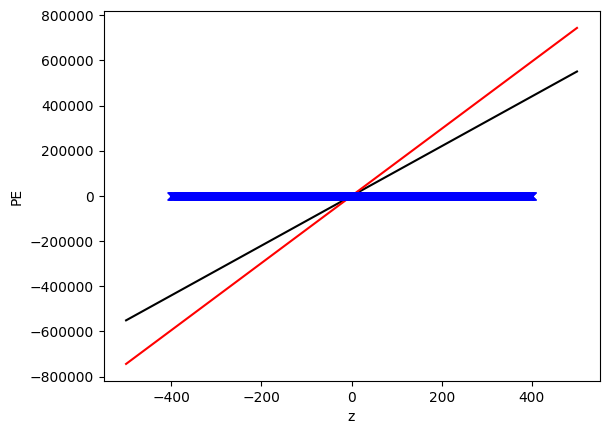

In [119]:
z_positions_exp = np.linspace(-box_length / 2, box_length / 2, num=1000)
pots_negative = gravitational_potential(z_positions_exp, density_difference, radius_negative)
pots_positive = gravitational_potential(z_positions_exp, density_difference, radius_positive)

plt.plot(z_positions_exp, pots_positive, color="k")
plt.plot(z_positions_exp, pots_negative, color="r")

plt.plot(x_positions, potential_vals, color='blue', marker="x")
plt.xlabel("z")
plt.ylabel("PE")


plt.show()